# Veículo no Plano XY — Filtro de Kalman com 6 Estados

Este notebook aplica o **Filtro de Kalman multivariável** para rastrear a posição, velocidade e
aceleração de um veículo no plano XY, a partir de medições ruidosas de posição.

O modelo assume **aceleração constante** em cada eixo, com perturbação de processo (aceleração
aleatória). O veículo percorre 15 s em linha reta e depois executa uma curva de 90° — um teste
severo, pois na curva a aceleração projetada em cada eixo varia, violando o modelo.

**Referência:** [Kalman Filter — Example 9](https://kalmanfilter.net/PT/default_pt.aspx)

## 1. Imports

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Carregamento dos Dados

| Coluna | Descrição |
|---|---|
| `n` | Número do passo de tempo (1 a 35) |
| `x_verdadeiro_m` | Posição verdadeira no eixo X [m] |
| `y_verdadeiro_m` | Posição verdadeira no eixo Y [m] |
| `medicao_x_m` | Medição ruidosa da posição X [m] |
| `medicao_y_m` | Medição ruidosa da posição Y [m] |

In [6]:
RAIZ = Path().resolve().parent.parent
CAMINHO = RAIZ / "arquivos" / "exemploB_veiculo.csv"

df = pd.read_csv(CAMINHO)
df.head(10)

,n,x_verdadeiro_m,y_verdadeiro_m,medicao_x_m,medicao_y_m
0,1,15.0,0.0,13.568,-0.065
1,2,30.0,0.0,31.970,-0.871
2,3,45.0,0.0,44.303,0.851
3,4,60.0,0.0,59.554,3.864
4,5,75.0,0.0,76.926,-1.667
5,6,90.0,0.0,95.474,-2.956
6,7,105.0,0.0,102.860,-3.009
7,8,120.0,0.0,124.045,-2.905
8,9,135.0,0.0,131.310,-4.293
9,10,150.0,0.0,150.525,-2.739


## 3. Espaço de Estados

O vetor de estados tem 6 componentes — posição, velocidade e aceleração em cada eixo:

$$\mathbf{x} = \begin{bmatrix} x & \dot{x} & \ddot{x} & y & \dot{y} & \ddot{y} \end{bmatrix}^T$$

### Dinâmica por eixo (aceleração constante)

Para cada eixo, os estados são $[p, v, a]$ e a física dá:

$$\mathbf{A}_1 = \begin{bmatrix} 0 & 1 & 0 \\ 0 & 0 & 1 \\ 0 & 0 & 0 \end{bmatrix}$$

### Matriz de transição $\mathbf{F}$ (6×6)

A série exata $\mathbf{F} = \mathbf{I} + \mathbf{A}\,\Delta t + \mathbf{A}^2\,\Delta t^2/2$ resulta em:

$$\mathbf{F} = \begin{bmatrix} \mathbf{F}_1 & \mathbf{0} \\ \mathbf{0} & \mathbf{F}_1 \end{bmatrix}, \quad \mathbf{F}_1 = \begin{bmatrix} 1 & \Delta t & \frac{\Delta t^2}{2} \\ 0 & 1 & \Delta t \\ 0 & 0 & 1 \end{bmatrix}$$

### Matriz de observação $\mathbf{H}$ (2×6)

O sensor mede apenas as posições $x$ (estado 0) e $y$ (estado 3):

$$\mathbf{H} = \begin{bmatrix} 1 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 & 0 & 0 \end{bmatrix}$$

### Covariância de medição $\mathbf{R}$ (2×2)

$$\mathbf{R} = \sigma_m^2 \cdot \mathbf{I}_2 = 9 \cdot \mathbf{I}_2 \quad (\sigma_m = 3 \text{ m})$$

### Covariância de processo $\mathbf{Q}$ (6×6)

Modelo de aceleração aleatória por eixo, com $\sigma_a = 0.2$ m/s²:

$$\mathbf{Q}_1 = \sigma_a^2 \begin{bmatrix} \frac{\Delta t^4}{4} & \frac{\Delta t^3}{2} & \frac{\Delta t^2}{2} \\ \frac{\Delta t^3}{2} & \Delta t^2 & \Delta t \\ \frac{\Delta t^2}{2} & \Delta t & 1 \end{bmatrix}, \quad \mathbf{Q} = \begin{bmatrix} \mathbf{Q}_1 & \mathbf{0} \\ \mathbf{0} & \mathbf{Q}_1 \end{bmatrix}$$

## 4. Parâmetros do Filtro

In [7]:
# Dados de medição
medicoes = df[["medicao_x_m", "medicao_y_m"]].to_numpy()

# Intervalo de amostragem
dt = 1.0

# --- Matriz de transição de estados (6×6) por blocos ---
F1 = np.array([[1, dt, 0.5 * dt**2], [0, 1, dt], [0, 0, 1]])

F = np.block([[F1, np.zeros((3, 3))], [np.zeros((3, 3)), F1]])

# --- Matriz de observação (2×6) ---
H = np.zeros((2, 6))
H[0, 0] = 1.0  # mede x
H[1, 3] = 1.0  # mede y

# --- Covariância de medição (2×2) ---
sigma_m = 3.0
R = sigma_m**2 * np.eye(2)

# --- Covariância de processo (6×6) por blocos ---
sigma_a = 0.2
Q1 = sigma_a**2 * np.array(
    [[dt**4 / 4, dt**3 / 2, dt**2 / 2], [dt**3 / 2, dt**2, dt], [dt**2 / 2, dt, 1]]
)

Q = np.block([[Q1, np.zeros((3, 3))], [np.zeros((3, 3)), Q1]])

# --- Estado inicial e covariância ---
x = np.zeros(6)
P = 500.0 * np.eye(6)

# Matriz identidade (6×6)
I6 = np.eye(6)

print("F =")
print(F)
print("\nH =")
print(H)
print("\nR =")
print(R)
print("\nQ =")
print(Q)

F =
[[1.  1.  0.5 0.  0.  0. ]
 [0.  1.  1.  0.  0.  0. ]
 [0.  0.  1.  0.  0.  0. ]
 [0.  0.  0.  1.  1.  0.5]
 [0.  0.  0.  0.  1.  1. ]
 [0.  0.  0.  0.  0.  1. ]]

H =
[[1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]]

R =
[[9. 0.]
 [0. 9.]]

Q =
[[0.01 0.02 0.02 0.   0.   0.  ]
 [0.02 0.04 0.04 0.   0.   0.  ]
 [0.02 0.04 0.04 0.   0.   0.  ]
 [0.   0.   0.   0.01 0.02 0.02]
 [0.   0.   0.   0.02 0.04 0.04]
 [0.   0.   0.   0.02 0.04 0.04]]


### Tabela de Parâmetros

| Parâmetro | Valor | Significado |
|---|---|---|
| $\Delta t$ | 1 s | Intervalo entre amostras |
| $\mathbf{F}$ | 6×6 (blocos) | Transição de estados |
| $\mathbf{H}$ | 2×6 | Observação (mede $x$ e $y$) |
| $\mathbf{R}$ | $9 \cdot \mathbf{I}_2$ | Variância do ruído de medição [m²] |
| $\sigma_a$ | 0.2 m/s² | Desvio padrão da aceleração de processo |
| $\mathbf{x}_0$ | $\mathbf{0}$ | Estado inicial (vetor nulo) |
| $\mathbf{P}_0$ | $500 \cdot \mathbf{I}_6$ | Covariância inicial (alta incerteza) |

## 5. Execução do Filtro de Kalman

Para cada medição $\mathbf{z}_k = [z_x, z_y]^T$, o filtro executa:

### Previsão
$$\hat{\mathbf{x}}_k^- = \mathbf{F}\,\hat{\mathbf{x}}_{k-1}^+$$
$$\mathbf{P}_k^- = \mathbf{F}\,\mathbf{P}_{k-1}^+\,\mathbf{F}^T + \mathbf{Q}$$

### Atualização
$$\mathbf{K}_k = \mathbf{P}_k^-\,\mathbf{H}^T\left(\mathbf{H}\,\mathbf{P}_k^-\,\mathbf{H}^T + \mathbf{R}\right)^{-1}$$
$$\hat{\mathbf{x}}_k^+ = \hat{\mathbf{x}}_k^- + \mathbf{K}_k\left(\mathbf{z}_k - \mathbf{H}\,\hat{\mathbf{x}}_k^-\right)$$
$$\mathbf{P}_k^+ = \left(\mathbf{I} - \mathbf{K}_k\,\mathbf{H}\right)\mathbf{P}_k^-\left(\mathbf{I} - \mathbf{K}_k\,\mathbf{H}\right)^T + \mathbf{K}_k\,\mathbf{R}\,\mathbf{K}_k^T$$

In [8]:
N = len(medicoes)
historico_x = np.zeros((N, 6))  # estados estimados
historico_P = np.zeros((N, 6, 6))  # covariâncias

for k, z in enumerate(medicoes):
    # --- Previsão ---
    x = F @ x
    P = F @ P @ F.T + Q

    # --- Atualização ---
    K = P @ H.T @ np.linalg.inv(H @ P @ H.T + R)
    x = x + K @ (z - H @ x)
    P = (I6 - K @ H) @ P @ (I6 - K @ H).T + K @ R @ K.T

    # Armazena resultado deste passo
    historico_x[k] = x
    historico_P[k] = P

print("--- Valores finais ---")
print(f"x  = {x[0]:.2f} m")
print(f"vx = {x[1]:.2f} m/s")
print(f"ax = {x[2]:.2f} m/s²")
print(f"y  = {x[3]:.2f} m")
print(f"vy = {x[4]:.2f} m/s")
print(f"ay = {x[5]:.2f} m/s²")

--- Valores finais ---
x  = 476.79 m
vx = 6.38 m/s
ax = -0.89 m/s²
y  = 137.95 m
vy = 13.41 m/s
ay = 0.72 m/s²


### Conferência com valores de referência

| Passo | x estim. (m) | vx estim. (m/s) | y estim. (m) | vy estim. (m/s) |
|-------|-------------|-----------------|-------------|----------------|
| 1 | 13.46 | 8.97 | -0.06 | -0.04 |
| 2 | 31.90 | 22.09 | -0.86 | -1.01 |
| 3 | 44.87 | 13.67 | 0.73 | 2.05 |
| 35 | 476.79 | 6.38 | 137.95 | 13.41 |

In [9]:
# Valores de referência (passos 1, 2, 3 e 35)
ref = {
    0: [13.46, 8.97, -0.06, -0.04],  # passo 1
    1: [31.90, 22.09, -0.86, -1.01],  # passo 2
    2: [44.87, 13.67, 0.73, 2.05],  # passo 3
    34: [476.79, 6.38, 137.95, 13.41],  # passo 35
}

print(
    f"{'Passo':<8} {'x':>8} {'vx':>8} {'y':>8} {'vy':>8}  │ {'x_ref':>8} {'vx_ref':>8} {'y_ref':>8} {'vy_ref':>8}"
)
print("-" * 90)
for k, vals in ref.items():
    linha = historico_x[k]
    print(
        f"{k+1:<8} {linha[0]:>8.2f} {linha[1]:>8.2f} {linha[3]:>8.2f} {linha[4]:>8.2f}"
        f"  │ {vals[0]:>8.2f} {vals[1]:>8.2f} {vals[2]:>8.2f} {vals[3]:>8.2f}"
    )

Passo           x       vx        y       vy  │    x_ref   vx_ref    y_ref   vy_ref
------------------------------------------------------------------------------------------
1           13.46     8.97    -0.06    -0.04  │    13.46     8.97    -0.06    -0.04
2           31.90    22.09    -0.86    -1.01  │    31.90    22.09    -0.86    -1.01
3           44.87    13.67     0.73     2.05  │    44.87    13.67     0.73     2.05
35         476.79     6.38   137.95    13.41  │   476.79     6.38   137.95    13.41


## 6. Métricas Estatísticas

Comparação entre a posição estimada pelo filtro e a posição verdadeira.

In [10]:
pos_verdadeira = df[["x_verdadeiro_m", "y_verdadeiro_m"]].to_numpy()
pos_estimada = historico_x[:, [0, 3]]

# Erro de posição (distância euclidiana)
erro_est = np.linalg.norm(pos_estimada - pos_verdadeira, axis=1)
erro_med = np.linalg.norm(medicoes - pos_verdadeira, axis=1)

# Ignora as 5 primeiras amostras (transiente)
erro_est_pos = erro_est[5:]
erro_med_pos = erro_med[5:]

print("Métrica                              Medição bruta  Filtro Kalman")
print("-" * 65)
print(
    f"{'RMSE [m]':<35} {np.sqrt(np.mean(erro_med_pos**2)):>14.4f} {np.sqrt(np.mean(erro_est_pos**2)):>14.4f}"
)
print(f"{'MAE [m]':<35} {np.mean(erro_med_pos):>14.4f} {np.mean(erro_est_pos):>14.4f}")
print(
    f"{'Erro máximo absoluto [m]':<35} {np.max(erro_med_pos):>14.4f} {np.max(erro_est_pos):>14.4f}"
)

Métrica                              Medição bruta  Filtro Kalman
-----------------------------------------------------------------
RMSE [m]                                    4.7240         3.7877
MAE [m]                                     4.2915         3.1605
Erro máximo absoluto [m]                    9.5181         8.3637


## 7. Visualização dos Resultados

### 7.1 Trajetória no Plano XY

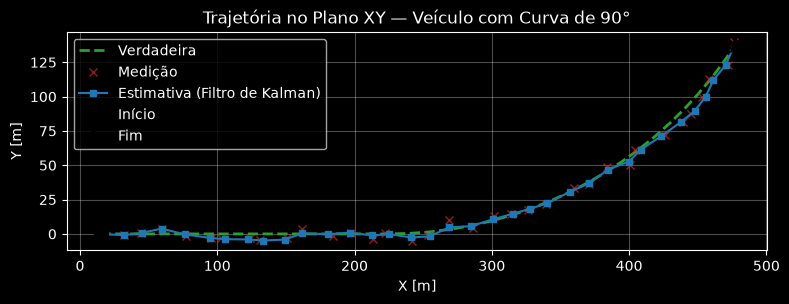

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(
    pos_verdadeira[:, 0],
    pos_verdadeira[:, 1],
    "--",
    label="Verdadeira",
    color="tab:green",
    linewidth=2,
)
ax.plot(
    medicoes[:, 0],
    medicoes[:, 1],
    "x",
    label="Medição",
    color="tab:red",
    markersize=6,
    alpha=0.7,
)
ax.plot(
    pos_estimada[:, 0],
    pos_estimada[:, 1],
    "s-",
    label="Estimativa (Filtro de Kalman)",
    color="tab:blue",
    markersize=4,
)

# Marca o início e o fim
ax.plot(pos_verdadeira[0, 0], pos_verdadeira[0, 1], "ko", markersize=10, label="Início")
ax.plot(pos_verdadeira[-1, 0], pos_verdadeira[-1, 1], "k*", markersize=12, label="Fim")

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_title("Trajetória no Plano XY — Veículo com Curva de 90°")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### 7.2 Ampliação da Região da Curva (passos 15–35)

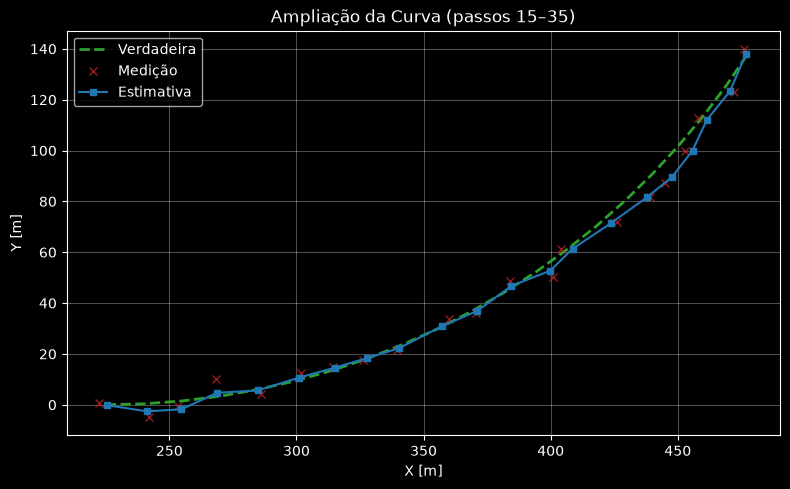

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(
    pos_verdadeira[14:, 0],
    pos_verdadeira[14:, 1],
    "--",
    label="Verdadeira",
    color="tab:green",
    linewidth=2,
)
ax.plot(
    medicoes[14:, 0],
    medicoes[14:, 1],
    "x",
    label="Medição",
    color="tab:red",
    markersize=6,
    alpha=0.7,
)
ax.plot(
    pos_estimada[14:, 0],
    pos_estimada[14:, 1],
    "s-",
    label="Estimativa",
    color="tab:blue",
    markersize=4,
)

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_title("Ampliação da Curva (passos 15–35)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### 7.3 Erro de Posição ao Longo do Tempo

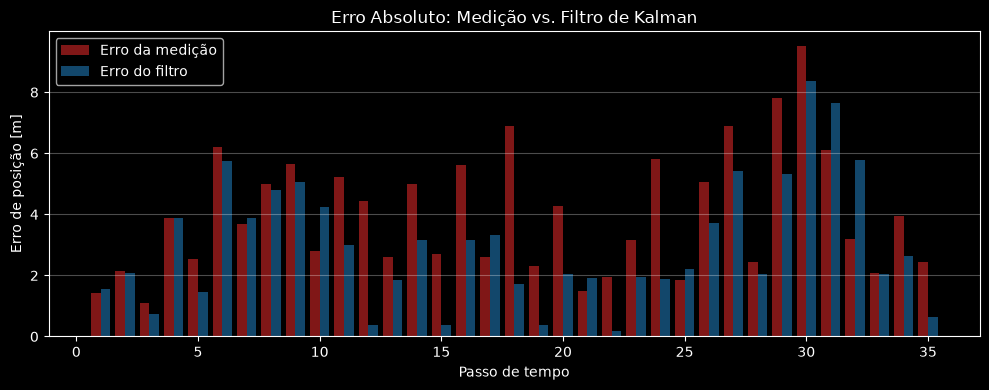

In [13]:
passos = np.arange(1, N + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    passos - 0.2,
    erro_med,
    width=0.4,
    label="Erro da medição",
    color="tab:red",
    alpha=0.6,
)
ax.bar(
    passos + 0.2,
    erro_est,
    width=0.4,
    label="Erro do filtro",
    color="tab:blue",
    alpha=0.6,
)
ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Erro de posição [m]")
ax.set_title("Erro Absoluto: Medição vs. Filtro de Kalman")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### 7.4 Evolução das Velocidades Estimadas

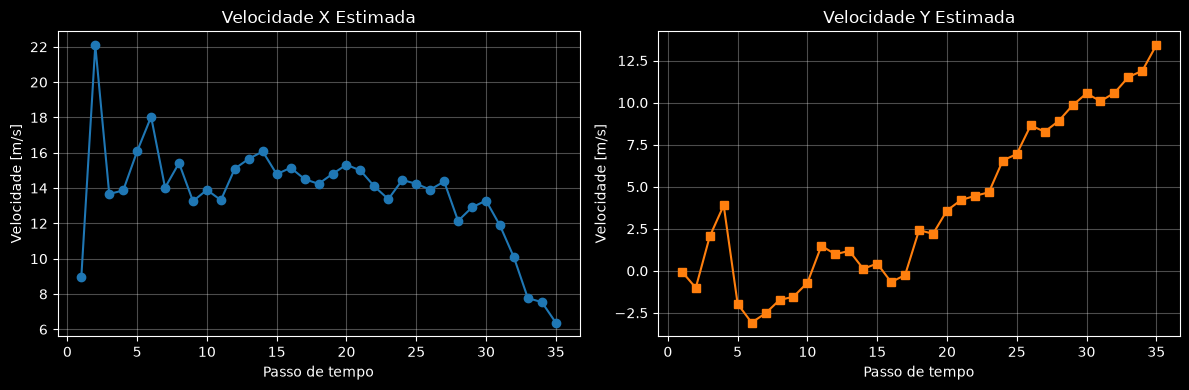

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Velocidade em X
axes[0].plot(passos, historico_x[:, 1], "o-", color="tab:blue")
axes[0].set_xlabel("Passo de tempo")
axes[0].set_ylabel("Velocidade [m/s]")
axes[0].set_title("Velocidade X Estimada")
axes[0].grid(True, alpha=0.3)

# Velocidade em Y
axes[1].plot(passos, historico_x[:, 4], "s-", color="tab:orange")
axes[1].set_xlabel("Passo de tempo")
axes[1].set_ylabel("Velocidade [m/s]")
axes[1].set_title("Velocidade Y Estimada")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.5 Evolução da Incerteza (Diagonal de $\mathbf{P}$)

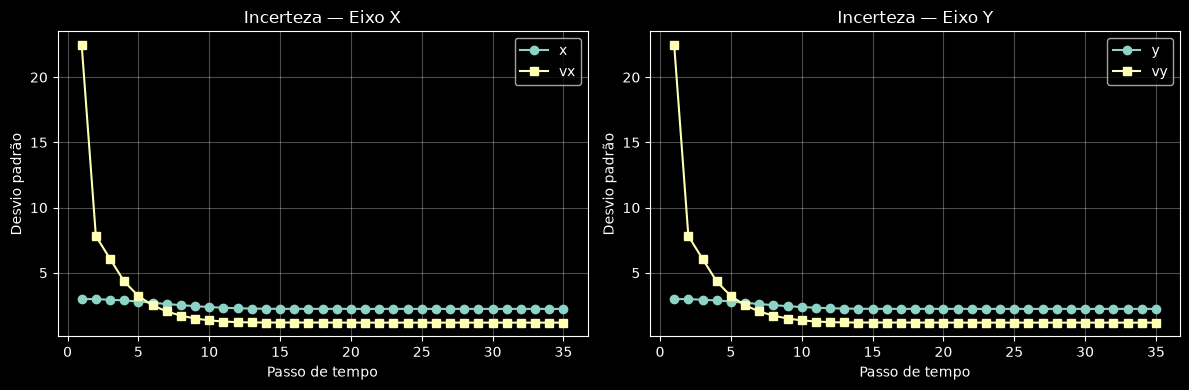

In [15]:
incerteza_x = np.sqrt(historico_P[:, 0, 0])
incerteza_vx = np.sqrt(historico_P[:, 1, 1])
incerteza_y = np.sqrt(historico_P[:, 3, 3])
incerteza_vy = np.sqrt(historico_P[:, 4, 4])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(passos, incerteza_x, "o-", label="x")
axes[0].plot(passos, incerteza_vx, "s-", label="vx")
axes[0].set_xlabel("Passo de tempo")
axes[0].set_ylabel("Desvio padrão")
axes[0].set_title("Incerteza — Eixo X")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(passos, incerteza_y, "o-", label="y")
axes[1].plot(passos, incerteza_vy, "s-", label="vy")
axes[1].set_xlabel("Passo de tempo")
axes[1].set_ylabel("Desvio padrão")
axes[1].set_title("Incerteza — Eixo Y")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()